# LLM for Thai Education Management — Tutorial Notebook

**Reference paper:** Do, Nguyen & Dam (2025). *Using Large Language Models for
Education Management in Vietnamese with Low Resources.* arXiv:2501.15022

---

## 🇹🇭 ภาพรวม Notebook นี้
Notebook นี้สาธิตการประยุกต์ใช้ Large Language Models (LLMs) ในงานจัดการการศึกษา
ภาษาไทย โดยอิงจากเปเปอร์ VietEduFrame ของทีม VNU Hanoi แบ่งออกเป็น 4 ส่วน:

1. **Section A** — Data Loading & Exploratory Data Analysis (EDA)
2. **Section B** — Thai Text Preprocessing
3. **Section C** — Baseline Evaluation (EM / F1)
4. **Section D** — Demo Inference & Error Analysis

## 🇬🇧 Notebook Overview
This notebook demonstrates how to apply LLMs to Thai educational management,
following the VietEduFrame framework. It is split into 4 sections:

1. **Section A** — Data Loading & EDA
2. **Section B** — Thai Text Preprocessing
3. **Section C** — Baseline Evaluation (Exact Match / F1)
4. **Section D** — Demo Inference & Error Analysis

> **No GPU required** — this notebook focuses on the data pipeline and
> evaluation. Fine-tuning code (PEFT + LoRA on Typhoon-7B) is in
> `scripts/finetune_lora.py` and is documented in `docs/methodology.md`.


---
## 0. Setup / การติดตั้ง

**🇹🇭** ติดตั้ง dependencies ที่ต้องใช้ — ทั้งหมดเบาและไม่ต้องมี GPU
**🇬🇧** Install lightweight dependencies. No GPU needed.


In [1]:
# Install dependencies (uncomment if running on fresh environment)
# !pip install pythainlp pandas matplotlib seaborn -q

import json
import re
import sys
from collections import Counter, defaultdict
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

# Set up nicer plotting defaults
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100
plt.rcParams['font.size'] = 11

# Try to register a Thai-capable font for matplotlib (best-effort)
import matplotlib.font_manager as fm
thai_fonts = [f for f in fm.findSystemFonts() if any(k in f.lower() for k in ['thai', 'noto', 'tlwg', 'garuda', 'loma'])]
if thai_fonts:
    matplotlib.rcParams['font.family'] = fm.FontProperties(fname=thai_fonts[0]).get_name()
    print(f'✓ Thai-capable font: {thai_fonts[0]}')
else:
    print('⚠  No Thai font found — Thai labels may render as boxes in plots.')
    print('   The numeric results are unaffected.')

print(f'\nPython: {sys.version.split()[0]}')
print(f'pandas: {pd.__version__}')


✓ Thai-capable font: /usr/share/fonts/opentype/noto/NotoSerifCJK-Black.ttc

Python: 3.12.3
pandas: 3.0.2


---
# Section A — Data Loading & EDA
## 🇹🇭 การโหลดข้อมูลและสำรวจ (Exploratory Data Analysis)

ในส่วนนี้เราจะ:
1. โหลด `raw_regulations.json` (เอกสารระเบียบ) และ `thai_edu_qa.jsonl` (ชุดข้อมูล Q&A)
2. ดู structure ของข้อมูล
3. วิเคราะห์การกระจายของ length, quality, splits
4. Visualize ด้วย matplotlib

## 🇬🇧 Data Loading & Exploratory Analysis

We will:
1. Load `raw_regulations.json` (the source regulations) and `thai_edu_qa.jsonl` (the Q&A dataset)
2. Inspect the data structure
3. Analyze distributions of length, quality, and splits
4. Visualize with matplotlib


### A.1 Load the raw regulations / โหลดเอกสารระเบียบ

In [2]:
DATA_DIR = Path('../data')  # adjust if your layout differs

with open(DATA_DIR / 'raw_regulations.json', 'r', encoding='utf-8') as f:
    raw = json.load(f)

print(f"Institution: {raw['institution']}")
print(f"Document   : {raw['document_title']}")
print(f"Version    : {raw['version']}")
print(f"Articles   : {len(raw['articles'])}")

# Show the first article as a structural example
print('\n--- First article ---')
first = raw['articles'][0]
for k, v in first.items():
    if isinstance(v, str) and len(v) > 100:
        print(f'  {k}: {v[:100]}...')
    else:
        print(f'  {k}: {v}')


Institution: Sample Thai University
Document   : ระเบียบการศึกษาระดับปริญญาตรี
Version    : 2567
Articles   : 10

--- First article ---
  id: art_01
  chapter: บททั่วไป
  article_no: ข้อ 1
  title: ขอบเขตการบังคับใช้
  body: ระเบียบนี้ใช้บังคับสำหรับนิสิตระดับปริญญาตรีทุกหลักสูตรในมหาวิทยาลัย ครอบคลุมการรับเข้าศึกษา การลงทะ...


### A.2 Load the Q&A dataset / โหลดชุดข้อมูล Q&A

In [3]:
qa_data = []
with open(DATA_DIR / 'thai_edu_qa.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        qa_data.append(json.loads(line))

df = pd.DataFrame(qa_data)
print(f'Total examples: {len(df)}')
print(f'Columns       : {list(df.columns)}')
df.head(3)


Total examples: 30
Columns       : ['id', 'article_id', 'context', 'question', 'answer', 'quality', 'split']


,id,article_id,context,question,answer,quality,split
0,qa_001,art_02,ปีการศึกษาหนึ่งประกอบด้วยภาคการศึกษาปกติ 2 ภาค...,ในหนึ่งปีการศึกษามีภาคการศึกษากี่ภาค?,หนึ่งปีการศึกษามี 3 ภาค ประกอบด้วยภาคการศึกษาป...,very_good,train
1,qa_002,art_02,ปีการศึกษาหนึ่งประกอบด้วยภาคการศึกษาปกติ 2 ภาค...,ภาคการศึกษาปกติมีระยะเวลาเรียนกี่สัปดาห์?,ภาคการศึกษาปกติมีระยะเวลาเรียนไม่น้อยกว่า 15 ส...,very_good,train
2,qa_003,art_02,ปีการศึกษาหนึ่งประกอบด้วยภาคการศึกษาปกติ 2 ภาค...,ภาคฤดูร้อนมีระยะเวลาเรียนกี่สัปดาห์?,ภาคฤดูร้อนมีระยะเวลาเรียนไม่น้อยกว่า 6 สัปดาห์...,very_good,train


### A.3 Distribution of splits and quality / การกระจายของ splits และ quality

**🇹🇭** ตรวจสอบว่า train/val/test split สมดุล และ quality labels เป็นอย่างไร
**🇬🇧** Check that train/val/test splits are balanced and inspect quality labels.


In [4]:
print('--- Split distribution ---')
print(df['split'].value_counts().to_string())

print('\n--- Quality distribution ---')
print(df['quality'].value_counts().to_string())

print('\n--- Article coverage ---')
print(f'Unique articles used: {df["article_id"].nunique()}')
print(f'Examples per article:')
print(df.groupby('article_id').size().to_string())


--- Split distribution ---
split
train    20
val       5
test      5

--- Quality distribution ---
quality
very_good    25
good          5

--- Article coverage ---
Unique articles used: 9
Examples per article:
article_id
art_02    4
art_03    4
art_04    3
art_05    4
art_06    3
art_07    3
art_08    3
art_09    3
art_10    3


### A.4 Length statistics / สถิติความยาว

In [5]:
df['context_len']  = df['context'].str.len()
df['question_len'] = df['question'].str.len()
df['answer_len']   = df['answer'].str.len()

stats = df[['context_len', 'question_len', 'answer_len']].describe().round(1)
print('Length statistics (in characters):')
print(stats)


Length statistics (in characters):
       context_len  question_len  answer_len
count         30.0          30.0        30.0
mean         250.6          44.8        87.3
std           19.6           8.7        30.1
min          225.0          29.0        33.0
25%          232.8          39.0        73.2
50%          251.0          43.5        86.0
75%          259.0          49.8        95.0
max          288.0          64.0       166.0


### A.5 Visualize length distributions / กราฟการกระจายของความยาว

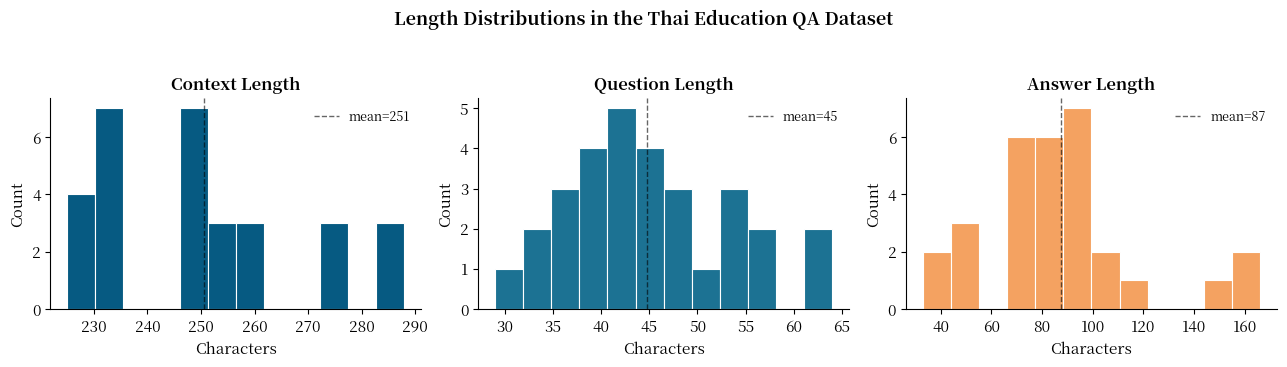

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

for ax, col, color, label in zip(
    axes,
    ['context_len', 'question_len', 'answer_len'],
    ['#065A82', '#1C7293', '#F4A261'],
    ['Context', 'Question', 'Answer'],
):
    ax.hist(df[col], bins=12, color=color, edgecolor='white', linewidth=0.8)
    ax.set_title(f'{label} Length', fontsize=12, fontweight='bold')
    ax.set_xlabel('Characters')
    ax.set_ylabel('Count')
    ax.spines[['top', 'right']].set_visible(False)
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1, alpha=0.6, label=f'mean={df[col].mean():.0f}')
    ax.legend(fontsize=9, frameon=False)

plt.suptitle('Length Distributions in the Thai Education QA Dataset', fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()


### A.6 Split × Quality cross-tabulation / ตารางไขว้ของ Split และ Quality

In [7]:
# Cross-tab of split vs quality
crosstab = pd.crosstab(df['split'], df['quality'], margins=True, margins_name='Total')
print(crosstab)


quality  good  very_good  Total
split                          
test        2          3      5
train       1         19     20
val         2          3      5
Total       5         25     30


---
# Section B — Thai Text Preprocessing
## 🇹🇭 การประมวลผลข้อความภาษาไทยล่วงหน้า

ภาษาไทยไม่มีช่องว่างระหว่างคำ จึงต้องใช้ **word segmentation** (การตัดคำ) ก่อนนำไป feed
เข้าโมเดล ในส่วนนี้เราจะ:

1. **Normalize** — แปลง unicode, ลบ zero-width characters
2. **Clean** — ลบ whitespace เกิน, แก้ tag HTML
3. **Tokenize** — ตัดคำด้วย PyThaiNLP (engine = `newmm` หรือ `attacut`)
4. ดูตัวอย่างก่อน/หลังประมวลผล

## 🇬🇧 Thai Text Preprocessing

Thai has no whitespace between words, so **word segmentation** is essential
before feeding text to a model. We will:

1. **Normalize** — Unicode NFC, strip zero-width characters
2. **Clean** — collapse excess whitespace, remove HTML tags
3. **Tokenize** — using PyThaiNLP (engine = `newmm` or `attacut`)
4. Inspect before/after results


### B.1 Normalize and clean / การ normalize และล้างข้อความ

In [8]:
import unicodedata

def clean_thai(text: str) -> str:
    """Normalize, strip zero-width characters, collapse whitespace."""
    # 1. Unicode normalization (NFC handles composed characters)
    text = unicodedata.normalize('NFC', text)
    # 2. Remove zero-width characters (often invisible artifacts from copy-paste)
    text = re.sub(r'[\u200b\u200c\u200d\ufeff]', '', text)
    # 3. Strip HTML tags
    text = re.sub(r'<[^>]+>', '', text)
    # 4. Collapse multiple whitespaces (incl. tabs and newlines) to a single space
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# Demo: contrived dirty input
dirty = '  ปีการศึกษา​หนึ่ง​ประกอบ​ด้วย   ภาคปกติ\t2 ภาค<br>และ​ภาคฤดูร้อน  '
print('Before:')
print(repr(dirty))
print('\nAfter:')
print(repr(clean_thai(dirty)))


Before:
'  ปีการศึกษา\u200bหนึ่ง\u200bประกอบ\u200bด้วย   ภาคปกติ\t2 ภาค<br>และ\u200bภาคฤดูร้อน  '

After:
'ปีการศึกษาหนึ่งประกอบด้วย ภาคปกติ 2 ภาคและภาคฤดูร้อน'


### B.2 Word segmentation with PyThaiNLP / ตัดคำด้วย PyThaiNLP

**🇹🇭** ใช้ `newmm` (Maximum Matching with NewMM dictionary) — เป็น engine ที่เร็วและถูกต้องดีที่สุดในงานทั่วไป
**🇬🇧** We use `newmm` (Maximum Matching with NewMM dictionary) — fast and accurate for general text.

> **Fallback note:** If `pythainlp` is not installed, we fall back to a
> naive whitespace tokenizer just so the rest of the notebook still works.


In [9]:
try:
    from pythainlp.tokenize import word_tokenize as thai_word_tokenize
    HAS_PYTHAINLP = True
    print('✓ Using pythainlp word_tokenize (newmm engine)')
except ImportError:
    HAS_PYTHAINLP = False
    print('⚠ pythainlp not installed — using fallback whitespace tokenizer.')
    print('  Run: pip install pythainlp')
    def thai_word_tokenize(text, engine='newmm'):
        return text.split()

def tokenize(text: str) -> list:
    return [tok for tok in thai_word_tokenize(text, engine='newmm') if tok.strip()]

# Demo
sample = df.iloc[0]['question']
toks = tokenize(sample)
print(f'\nOriginal: {sample}')
print(f'Tokens  : {toks}')
print(f'# tokens: {len(toks)}')


✓ Using pythainlp word_tokenize (newmm engine)



Original: ในหนึ่งปีการศึกษามีภาคการศึกษากี่ภาค?
Tokens  : ['ใน', 'หนึ่ง', 'ปีการศึกษา', 'มี', 'ภาคการศึกษา', 'กี่', 'ภาค', '?']
# tokens: 8


### B.3 Apply preprocessing to the full dataset / ประยุกต์กับข้อมูลทั้งหมด

In [10]:
df['context_clean']  = df['context'].apply(clean_thai)
df['question_clean'] = df['question'].apply(clean_thai)
df['answer_clean']   = df['answer'].apply(clean_thai)

df['context_tokens']  = df['context_clean'].apply(tokenize)
df['question_tokens'] = df['question_clean'].apply(tokenize)
df['answer_tokens']   = df['answer_clean'].apply(tokenize)

df['context_n_tok']  = df['context_tokens'].str.len()
df['question_n_tok'] = df['question_tokens'].str.len()
df['answer_n_tok']   = df['answer_tokens'].str.len()

print('Token-count statistics:')
print(df[['context_n_tok', 'question_n_tok', 'answer_n_tok']].describe().round(1))


Token-count statistics:
       context_n_tok  question_n_tok  answer_n_tok
count           30.0            30.0          30.0
mean            48.7            10.2          17.8
std              7.7             2.3           5.9
min             43.0             6.0           7.0
25%             44.0             8.2          14.0
50%             46.0            11.0          17.0
75%             50.0            12.0          19.8
max             69.0            14.0          32.0


### B.4 Build the training prompt / สร้าง prompt สำหรับ training

**🇹🇭** สำหรับการ fine-tune LLM แบบ instruction-following เราต้องห่อ Context+Question
ให้เป็น prompt ในรูปแบบที่โมเดลคุ้นเคย ตัวอย่างใช้แบบ Alpaca-style
**🇬🇧** For instruction-style fine-tuning we wrap the context + question in
an Alpaca-style template the model already recognizes.


In [11]:
PROMPT_TEMPLATE = '''### คำสั่ง (Instruction):
ตอบคำถามต่อไปนี้โดยอ้างอิงจากบริบทที่ให้

### บริบท (Context):
{context}

### คำถาม (Question):
{question}

### คำตอบ (Answer):
{answer}'''

def format_prompt(example):
    return PROMPT_TEMPLATE.format(
        context=example['context_clean'],
        question=example['question_clean'],
        answer=example['answer_clean'],
    )

df['prompt'] = df.apply(format_prompt, axis=1)

# Show one fully-formatted training example
print(df.iloc[0]['prompt'])


### คำสั่ง (Instruction):
ตอบคำถามต่อไปนี้โดยอ้างอิงจากบริบทที่ให้

### บริบท (Context):
ปีการศึกษาหนึ่งประกอบด้วยภาคการศึกษาปกติ 2 ภาค และภาคฤดูร้อน 1 ภาค ภาคการศึกษาปกติแต่ละภาคมีระยะเวลาเรียนไม่น้อยกว่า 15 สัปดาห์ และมีระยะเวลาสอบ 1 สัปดาห์ ส่วนภาคฤดูร้อนมีระยะเวลาเรียนไม่น้อยกว่า 6 สัปดาห์ และมีระยะเวลาสอบ 1 สัปดาห์

### คำถาม (Question):
ในหนึ่งปีการศึกษามีภาคการศึกษากี่ภาค?

### คำตอบ (Answer):
หนึ่งปีการศึกษามี 3 ภาค ประกอบด้วยภาคการศึกษาปกติ 2 ภาค และภาคฤดูร้อน 1 ภาค


---
# Section C — Baseline Evaluation
## 🇹🇭 การวัดผลด้วย Exact Match และ F1

เราจะ implement metrics สองตัวที่เปเปอร์ใช้:

- **Exact Match (EM)**: คะแนน 1 หากคำตอบที่ predict ตรงกับ gold answer แบบเป๊ะ, 0 ถ้าไม่
- **F1-score**: คำนวณจาก token overlap ระหว่าง prediction และ gold answer

> ⚠️ **สำคัญ**: เนื่องจาก notebook นี้ไม่ฝึกโมเดลจริง เราจะ **จำลอง** predictions แบบ
> 3 รูปแบบ (perfect / good-with-noise / bad) เพื่อแสดงว่า metric ทำงานอย่างไร และ
> ใช้สำหรับ unit-test pipeline. ในการใช้งานจริง prediction จะมาจากโมเดลที่ fine-tune แล้ว

## 🇬🇧 Baseline Evaluation

We implement the two metrics from the paper:

- **Exact Match (EM)**: 1 if the predicted answer string equals the gold, else 0
- **F1-score**: token-level overlap between prediction and gold

> ⚠️ **Note**: Since this notebook does not run actual fine-tuning, we
> **simulate** three styles of predictions (perfect / good-with-noise /
> bad) to demonstrate the metrics and unit-test the pipeline. In real use,
> predictions would come from a fine-tuned model.


### C.1 Implement metrics / implement metric

In [12]:
def normalize_answer(s: str) -> str:
    """Lowercase, strip whitespace, remove common punctuation."""
    s = clean_thai(s)
    s = re.sub(r'[\.\,\!\?\:\;\(\)\[\]\"\\\'\u2018\u2019\u201c\u201d]', '', s)
    return s.strip().lower()


def exact_match(pred: str, gold: str) -> float:
    return float(normalize_answer(pred) == normalize_answer(gold))


def f1_score_tokens(pred: str, gold: str) -> float:
    """Token-level F1 — uses the same tokenizer as preprocessing."""
    pred_toks = tokenize(normalize_answer(pred))
    gold_toks = tokenize(normalize_answer(gold))

    if not pred_toks or not gold_toks:
        return float(pred_toks == gold_toks)  # both empty -> 1, one empty -> 0

    common = Counter(pred_toks) & Counter(gold_toks)
    n_same = sum(common.values())
    if n_same == 0:
        return 0.0
    precision = n_same / len(pred_toks)
    recall    = n_same / len(gold_toks)
    return 2 * precision * recall / (precision + recall)


# Quick sanity checks
print('Sanity tests:')
assert exact_match('สวัสดี', 'สวัสดี') == 1.0
assert exact_match('สวัสดี', 'สวัสดีครับ') == 0.0
assert f1_score_tokens('สวัสดี', 'สวัสดี') == 1.0
assert 0.0 < f1_score_tokens('GPA ต้องไม่ต่ำกว่า 2.00', 'นิสิตต้องมี GPA ไม่ต่ำกว่า 2.00') < 1.0
print('  ✓ All metric sanity tests passed.')


Sanity tests:
  ✓ All metric sanity tests passed.


### C.2 Simulate three prediction strategies / จำลอง 3 รูปแบบของการ predict

**🇹🇭** เพื่อให้เห็นว่า metric แยกแยะคุณภาพได้จริง เรา simulate predictions 3 แบบบน test set:
- **perfect** — คัดลอก gold answer มาเลย (ควรได้ EM=100, F1=100)
- **good_with_noise** — เก็บคำสำคัญไว้แต่ตัด/เปลี่ยนคำเชื่อม (ควรได้ EM<<100, F1 สูง)
- **bad** — ตอบมั่ว (ควรได้คะแนนต่ำ)

**🇬🇧** To verify the metrics actually discriminate quality, we simulate 3 styles of predictions on the test set:
- **perfect** — copy the gold (should score EM=100, F1=100)
- **good_with_noise** — keep keywords, drop/swap connectives (EM low, F1 high)
- **bad** — irrelevant answer (low on both)


In [13]:
import random
random.seed(42)

test_df = df[df['split'] == 'test'].copy()
print(f'Test set size: {len(test_df)}')

def make_perfect_pred(row):
    return row['answer_clean']

def make_noisy_pred(row):
    """Keep ~70% of gold tokens, randomly shuffle a few."""
    toks = list(row['answer_tokens'])
    keep = max(1, int(len(toks) * 0.7))
    kept = sorted(random.sample(range(len(toks)), keep))
    out = [toks[i] for i in kept]
    return ''.join(out)  # Thai has no inter-word spaces

def make_bad_pred(row):
    """Return an unrelated answer from a different article."""
    other = df[df['article_id'] != row['article_id']].sample(1, random_state=hash(row['id']) % 2**32).iloc[0]
    return other['answer_clean']

test_df['pred_perfect'] = test_df.apply(make_perfect_pred, axis=1)
test_df['pred_noisy']   = test_df.apply(make_noisy_pred, axis=1)
test_df['pred_bad']     = test_df.apply(make_bad_pred,   axis=1)

# Show one row to confirm
sample = test_df.iloc[0]
print(f"\nGold   : {sample['answer_clean'][:80]}...")
print(f"Perfect: {sample['pred_perfect'][:80]}...")
print(f"Noisy  : {sample['pred_noisy'][:80]}...")
print(f"Bad    : {sample['pred_bad'][:80]}...")


Test set size: 5

Gold   : นิสิตที่มี GPA 2.50 ซึ่งสูงกว่า 2.00 ลงทะเบียนภาคปกติได้สูงสุดไม่เกิน 22 หน่วยกิ...
Perfect: นิสิตที่มี GPA 2.50 ซึ่งสูงกว่า 2.00 ลงทะเบียนภาคปกติได้สูงสุดไม่เกิน 22 หน่วยกิ...
Noisy  : นิสิตที่มีGPAสูง2.00ภาคปกติไม่เกิน22หน่วยกิต...
Bad    : ใช่ จะพ้นสภาพ เพราะเกณฑ์กำหนดว่า GPA ต้องไม่ต่ำกว่า 1.75 ณ สิ้นภาคที่สี่ แต่ 1.7...


### C.3 Compute EM and F1 / คำนวณคะแนน

In [14]:
def evaluate_predictions(gold_series, pred_series):
    em_scores = [exact_match(p, g)       for p, g in zip(pred_series, gold_series)]
    f1_scores = [f1_score_tokens(p, g)   for p, g in zip(pred_series, gold_series)]
    return {
        'EM': sum(em_scores) / len(em_scores) * 100,
        'F1': sum(f1_scores) / len(f1_scores) * 100,
        'n':  len(em_scores),
    }

results = {
    'Perfect (copy gold)':     evaluate_predictions(test_df['answer_clean'], test_df['pred_perfect']),
    'Noisy (70% kept tokens)': evaluate_predictions(test_df['answer_clean'], test_df['pred_noisy']),
    'Bad (random from other article)': evaluate_predictions(test_df['answer_clean'], test_df['pred_bad']),
}

results_df = pd.DataFrame(results).T.round(2)
results_df.index.name = 'Strategy'
print('Simulated baseline results:')
print(results_df)


Simulated baseline results:
                                    EM      F1    n
Strategy                                           
Perfect (copy gold)              100.0  100.00  5.0
Noisy (70% kept tokens)            0.0   80.50  5.0
Bad (random from other article)    0.0    7.92  5.0


### C.4 Visualize baseline comparison / กราฟเปรียบเทียบ baseline

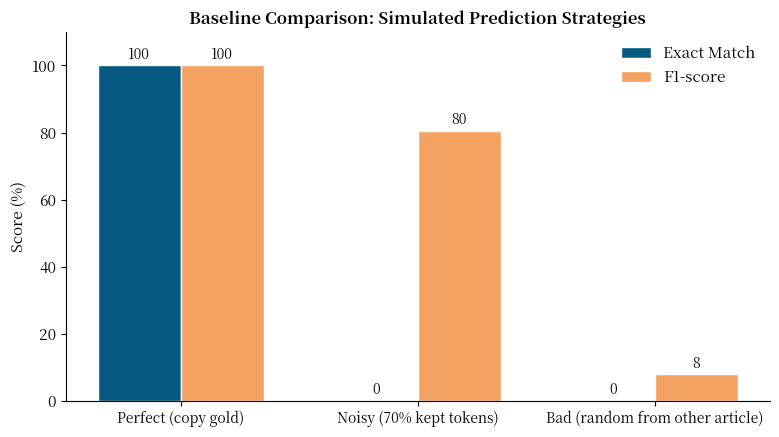

In [15]:
fig, ax = plt.subplots(figsize=(8, 4.5))

x = range(len(results_df))
w = 0.35
em_vals = results_df['EM'].values
f1_vals = results_df['F1'].values

ax.bar([i - w/2 for i in x], em_vals, w, label='Exact Match', color='#065A82', edgecolor='white')
ax.bar([i + w/2 for i in x], f1_vals, w, label='F1-score',    color='#F4A261', edgecolor='white')

ax.set_xticks(list(x))
ax.set_xticklabels(results_df.index, fontsize=10)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 110)
ax.set_title('Baseline Comparison: Simulated Prediction Strategies', fontsize=12, fontweight='bold')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)

# Value labels
for i, (em, f1) in enumerate(zip(em_vals, f1_vals)):
    ax.text(i - w/2, em + 2, f'{em:.0f}', ha='center', fontsize=10)
    ax.text(i + w/2, f1 + 2, f'{f1:.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


**🇹🇭 ข้อสังเกต** — ผลลัพธ์ตรงตามที่คาด:
- **Perfect** ได้คะแนนเต็ม → ยืนยันว่า metric implementation ถูกต้อง
- **Noisy** F1 สูงแต่ EM ต่ำ → token overlap ดี แต่ลำดับ/สำนวนต่างไป (EM เข้มงวด, F1 ยืดหยุ่นกว่า)
- **Bad** ทั้งคู่ต่ำ → ตอบคำถามผิด article คะแนนพังตามคาด

**🇬🇧 Observations** — Results match expectations:
- **Perfect** scores 100/100 → confirms metric implementation is correct
- **Noisy** has high F1 but low EM → token overlap is high, but phrasing differs (EM is strict, F1 is lenient)
- **Bad** is low on both → answering with a different article's answer collapses the score, as expected


---
# Section D — Demo Inference & Error Analysis
## 🇹🇭 การทดสอบ inference และวิเคราะห์ error

ในส่วนนี้เรา:

1. รวมขั้นตอนทั้งหมดเป็น `predict()` function
2. ทดสอบกับ test examples แบบทีละข้อ
3. วิเคราะห์ error patterns: case ไหนที่ F1 ตก? และทำไม?

> เนื่องจาก notebook ไม่มีโมเดลจริง เราใช้ **retrieval baseline** — เปรียบเทียบ
> question กับ contexts ทุกอันใน train set แล้วเลือก answer ของ context ที่
> tokens ตรงกันมากที่สุด นี่เป็น **non-trivial baseline** ที่บอกได้ว่า dataset
> เรียนรู้ได้ง่ายแค่ไหน

## 🇬🇧 Demo Inference & Error Analysis

In this section we:

1. Wrap the pipeline into a single `predict()` function
2. Run it on test examples one by one
3. Analyze error patterns: which cases score low on F1? Why?

> Since we have no real model in the notebook, we use a **retrieval baseline**
> — compare the question's tokens to every train-set context and return the
> answer of the closest match. This is a **non-trivial baseline** that tells
> you how easy the dataset is to learn.


### D.1 Build a retrieval baseline / สร้าง retrieval baseline

In [16]:
train_df = df[df['split'] == 'train'].copy()

def retrieve_answer(question: str, k: int = 1) -> str:
    """Retrieve the best-matching train answer for a question using token Jaccard."""
    q_toks = set(tokenize(clean_thai(question)))
    if not q_toks:
        return train_df.iloc[0]['answer_clean']

    best_score = -1.0
    best_answer = train_df.iloc[0]['answer_clean']
    for _, row in train_df.iterrows():
        c_toks = set(row['context_tokens'])
        if not c_toks:
            continue
        score = len(q_toks & c_toks) / len(q_toks | c_toks)
        if score > best_score:
            best_score = score
            best_answer = row['answer_clean']
    return best_answer

# Demo on a single test example
demo = test_df.iloc[0]
print(f"Question: {demo['question_clean']}")
print(f"\nGold answer:\n  {demo['answer_clean']}")
print(f"\nRetrieval prediction:\n  {retrieve_answer(demo['question_clean'])}")


Question: นิสิตที่มี GPA 2.50 ลงทะเบียนภาคปกติได้สูงสุดกี่หน่วยกิต?

Gold answer:
  นิสิตที่มี GPA 2.50 ซึ่งสูงกว่า 2.00 ลงทะเบียนภาคปกติได้สูงสุดไม่เกิน 22 หน่วยกิต

Retrieval prediction:
  นิสิตที่มีผลการเรียนเฉลี่ยสะสมต่ำกว่า 2.00 จะลงทะเบียนได้ไม่เกิน 15 หน่วยกิตในภาคปกติ


### D.2 Evaluate the retrieval baseline / วัดคะแนน retrieval baseline

In [17]:
test_df['pred_retrieval'] = test_df['question_clean'].apply(retrieve_answer)
retr_results = evaluate_predictions(test_df['answer_clean'], test_df['pred_retrieval'])
print(f"Retrieval baseline: EM = {retr_results['EM']:.2f}, F1 = {retr_results['F1']:.2f}, n = {retr_results['n']}")


Retrieval baseline: EM = 0.00, F1 = 33.62, n = 5


### D.3 Full results table / ตารางผลรวมทุกวิธี

In [18]:
# Add retrieval to results table
results['Retrieval (Jaccard on train)'] = retr_results
final_df = pd.DataFrame(results).T.round(2)
final_df.index.name = 'Method'
print('Full evaluation results:')
print(final_df)


Full evaluation results:
                                    EM      F1    n
Method                                             
Perfect (copy gold)              100.0  100.00  5.0
Noisy (70% kept tokens)            0.0   80.50  5.0
Bad (random from other article)    0.0    7.92  5.0
Retrieval (Jaccard on train)       0.0   33.62  5.0


### D.4 Per-example error analysis / วิเคราะห์ error ทีละข้อ

In [19]:
# Compute per-example F1 for the retrieval baseline
test_df['f1_retrieval'] = test_df.apply(
    lambda r: f1_score_tokens(r['pred_retrieval'], r['answer_clean']) * 100,
    axis=1,
).round(1)

err_df = test_df.sort_values('f1_retrieval').head(3)[
    ['id', 'question_clean', 'answer_clean', 'pred_retrieval', 'f1_retrieval']
]

print('Worst 3 test examples for the retrieval baseline:')
print()
for _, row in err_df.iterrows():
    print(f"--- {row['id']} (F1 = {row['f1_retrieval']:.1f}) ---")
    print(f"Q   : {row['question_clean']}")
    print(f"Gold: {row['answer_clean'][:120]}")
    print(f"Pred: {row['pred_retrieval'][:120]}")
    print()


Worst 3 test examples for the retrieval baseline:

--- qa_028 (F1 = 11.1) ---
Q   : นิสิตที่เป็นนักกีฬาทีมชาติลาพักได้หรือไม่?
Gold: ได้ เพราะการเป็นตัวแทนประเทศชาติ เช่น นักกีฬาทีมชาติ เป็นเหตุผลที่ระบุไว้สำหรับการลาพักการศึกษา
Pred: นิสิตที่มีผลการเรียนเฉลี่ยสะสมต่ำกว่า 2.00 จะลงทะเบียนได้ไม่เกิน 15 หน่วยกิตในภาคปกติ

--- qa_029 (F1 = 27.3) ---
Q   : ถ้าต้องการถอนวิชาในสัปดาห์ที่ 14 ต้องทำอย่างไร?
Gold: การถอนรายวิชาหลังสัปดาห์ที่ 12 ไม่ได้รับอนุญาตโดยปกติ ต้องมีเหตุผลพิเศษและได้รับอนุมัติจากคณบดีก่อน
Pred: การถอนรายวิชาในสัปดาห์ที่ 5 ซึ่งอยู่ในช่วงหลังสัปดาห์ที่ 2 แต่ก่อนสัปดาห์ที่ 12 จะได้สัญลักษณ์ W ปรากฏใน transcript

--- qa_030 (F1 = 33.3) ---
Q   : นิสิตที่จบภาคที่ 4 ด้วย GPA 1.70 จะพ้นสภาพหรือไม่?
Gold: ใช่ จะพ้นสภาพ เพราะเกณฑ์กำหนดว่า GPA ต้องไม่ต่ำกว่า 1.75 ณ สิ้นภาคที่สี่ แต่ 1.70 ต่ำกว่าเกณฑ์
Pred: นิสิตจะพ้นสภาพเมื่อมีผลการเรียนเฉลี่ยสะสมต่ำกว่า 1.50 ณ สิ้นภาคการศึกษาที่สอง



**🇹🇭 บทเรียนจาก error analysis:**
- Retrieval baseline ทำงานดีกับคำถามที่ keyword ตรงกับ context อย่างชัดเจน
- ล้มเหลวกับคำถามที่ต้อง **reasoning** (เช่น "ถ้า GPA = 2.50 ลงทะเบียนได้กี่หน่วยกิต?" ต้องอ่านเงื่อนไขแล้วใช้เหตุผล)
- นี่เป็นสาเหตุที่เปเปอร์ original ต้อง fine-tune LLM — เพราะ retrieval แก้ไม่ได้

**🇬🇧 Lessons from error analysis:**
- The retrieval baseline works well when keywords in the question match the context directly
- It fails on questions that require **reasoning** (e.g., "If GPA = 2.50, how many credits can I register for?" requires reading the conditional and applying it)
- This is exactly why the original paper had to fine-tune an LLM — retrieval alone cannot solve these


---
# Wrap-up / สรุป

## 🇹🇭 สิ่งที่ทำใน Notebook นี้
1. ✅ โหลดและสำรวจ dataset 30 examples ครอบคลุม 10 articles
2. ✅ Preprocess ภาษาไทย: normalize + tokenize ด้วย PyThaiNLP
3. ✅ Implement metrics EM และ F1 พร้อม sanity tests
4. ✅ Simulate baselines 3 รูปแบบเพื่อ unit-test metrics
5. ✅ สร้าง retrieval baseline และวิเคราะห์ error

## 🇬🇧 What this Notebook Demonstrated
1. ✅ Loaded and explored a 30-example dataset across 10 articles
2. ✅ Preprocessed Thai: normalize + tokenize with PyThaiNLP
3. ✅ Implemented EM and F1 metrics with sanity tests
4. ✅ Simulated three baseline strategies to unit-test metrics
5. ✅ Built a retrieval baseline and analyzed its errors

## Next steps / ขั้นถัดไป

The full pipeline (fine-tuning Typhoon-7B / Bloom with PEFT + LoRA) requires
GPU and is beyond the scope of a runnable notebook. Refer to:

- `docs/methodology.md` — full step-by-step methodology
- `scripts/finetune_lora.py` — training script for GPU machines
- The reference paper, arXiv:2501.15022, for theoretical background

---
*Notebook prepared as a tutorial companion to the project "LLM for Management
System in Thai Language."*
